# Topic Modelling and Theme Discovery

This notebook explores the review corpus with unsupervised methods in order to identify recurring themes.

The workflow is structured as follows:
1. Data preparation and topic-oriented text cleaning
2. Baseline and LDA topic modelling
3. Embedding-based clustering with Word2Vec and KMeans
4. Final comparison of the two topic-discovery approaches
5. Zero-shot classification

## Data Preparation and topic-oriented text cleaning

### Imports

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from gensim.models import Word2Vec, CoherenceModel
from gensim.corpora import Dictionary

from tqdm import tqdm
tqdm.pandas()

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
np.random.seed(42)


### Loading the review corpus

The notebook keeps the two cleaned text fields used later for:
- bag-of-words topic modelling
- embedding-based clustering

After removing empty rows, the corpus contains **5995 reviews**, which provides a sufficiently large basis for unsupervised theme discovery.

In [3]:
df = pd.read_csv('dataset_cleaned.csv')
df_topic = df[['avis_en_tfidf_lda', 'avis_en_embeddings']].copy()
df_topic['avis_en_tfidf_lda'] = df_topic['avis_en_tfidf_lda'].fillna('').astype(str)
df_topic['avis_en_embeddings'] = df_topic['avis_en_embeddings'].fillna('').astype(str)

df_topic = df_topic[
    (df_topic['avis_en_tfidf_lda'].str.strip() != '')
    & (df_topic['avis_en_embeddings'].str.strip() != '')
].reset_index(drop=True)

print(df_topic.shape)
df_topic.head()

(5995, 2)


,avis_en_tfidf_lda,avis_en_embeddings
0,best prices solutions listening speed recommen...,best insurance prices solutions listening spee...
1,generally satisfied problem internal site impo...,"I am generally satisfied, except that you have..."
2,affordable price options available box connect...,very affordable price several options are avai...
3,satisfied quick response thank cheapest market...,"I am satisfied with the service, a very quick ..."
4,years disappointed mutual longer mutual search...,customer for more than years very disappointed...


### Topic-oriented cleaning strategy

A stronger cleaning pipeline is applied to improve topic interpretability. In addition to standard normalization, the notebook removes generic review words such as `service`, `company`, `customer`, `price`, and `recommend`.

The objective is to reduce very frequent but weakly informative words so that the models focus more clearly on concrete themes such as claims, contracts, vehicles, payments, or advisors.

In [4]:
BASE_STOPWORDS = set(ENGLISH_STOP_WORDS)

CUSTOM_STOPWORDS = {
    'the', 'and', 'for', 'that', 'this', 'with', 'from', 'have', 'has', 'had', 'was', 'were', 'are',
    'will', 'would', 'can', 'could', 'very', 'much', 'more', 'less', 'also', 'still', 'yet', 'one',
    'two', 'get', 'got', 'made', 'make', 'go', 'goes', 'went', 'come', 'came', 'back', 'really',
    'im', 'ive', 'youre', 'theyre', 'didnt', 'doesnt', 'cant', 'wont', 'dont', 'isnt', 'wasnt',
    'service', 'services', 'company', 'insurance', 'insurer', 'customer', 'customers', 'client',
    'clients', 'opinion', 'opinions', 'regards', 'thank', 'thanks', 'best', 'good', 'great',
    'bad', 'new', 'old', 'years', 'year', 'months', 'month', 'days', 'day', 'time', 'times',
    'price', 'prices', 'satisfied', 'recommend', 'contact', 'telephone', 'online', 'site'
}

STOPWORDS = BASE_STOPWORDS | CUSTOM_STOPWORDS

CONTRACTIONS = {
    "can't": 'cannot',
    "won't": 'will not',
    "n't": ' not',
    "'re": ' are',
    "'ve": ' have',
    "'ll": ' will',
    "'d": ' would',
    "'m": ' am',
    "'s": ''
}

### Normalizing and cleaning the review text

This step prepares the review text for theme extraction.

Two functions are applied:

- `normalize_text()` standardizes the text format
- `clean_for_topics()` removes weakly informative tokens

The objective is to reduce noise and keep clearer words for topic modelling and clustering. To do this, several transformations are applied:

- lowercase conversion
- removal of URLs, digits, punctuation, and extra spaces
- expansion of common contractions
- removal of short tokens and stopwords
- removal of tokens with very low semantic value

In [5]:
def normalize_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    for old, new in CONTRACTIONS.items():
        text = text.replace(old, new)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def clean_for_topics(text: str, min_len: int = 3) -> str:
    text = normalize_text(text)
    tokens = []
    for token in text.split():
        if len(token) < min_len:
            continue
        if token in STOPWORDS:
            continue
        if token.isdigit():
            continue
        if len(set(token)) == 1:
            continue
        tokens.append(token)
    return ' '.join(tokens)

df_topic['raw_lda_text'] = df_topic['avis_en_tfidf_lda'].map(normalize_text)
df_topic['raw_emb_text'] = df_topic['avis_en_embeddings'].map(normalize_text)
df_topic['clean_lda_text'] = df_topic['avis_en_tfidf_lda'].map(clean_for_topics)
df_topic['clean_emb_text'] = df_topic['avis_en_embeddings'].map(clean_for_topics)

df_topic = df_topic[
    (df_topic['clean_lda_text'].str.strip() != '')
    & (df_topic['clean_emb_text'].str.strip() != '')
].reset_index(drop=True)

print(df_topic.shape)
df_topic[['avis_en_tfidf_lda', 'clean_lda_text']].head(10)


(5989, 6)


,avis_en_tfidf_lda,clean_lda_text
0,best prices solutions listening speed recommen...,solutions listening speed attractive quality s...
1,generally satisfied problem internal site impo...,generally problem internal impossible declare ...
2,affordable price options available box connect...,affordable options available box connected car...
3,satisfied quick response thank cheapest market...,quick response cheapest market
4,years disappointed mutual longer mutual search...,disappointed mutual longer mutual search immed...
5,forced sale telephone claiming events loved on...,forced sale claiming events loved ones knowing...
6,new satisfied price opinions new hope goes thank,hope
7,contacted telephone sell puppy selling pretty ...,contacted sell puppy selling pretty details su...
8,join negative reviews regret having star reimb...,join negative reviews regret having star reimb...
9,generali life assets poor bad payer ask advanc...,generali life assets poor payer ask advance ge...


### Impact of cleaning on text length

In [6]:
raw_lengths = df_topic['raw_lda_text'].str.split().map(len)
clean_lengths = df_topic['clean_lda_text'].str.split().map(len)

stats_df = pd.DataFrame({
    'raw_tokens': raw_lengths.describe(),
    'clean_tokens': clean_lengths.describe(),
})
stats_df


,raw_tokens,clean_tokens
count,5989.000000,5989.000000
mean,23.889297,20.920855
std,25.896986,24.251688
min,1.000000,1.000000
25%,11.000000,8.000000
50%,15.000000,12.000000
75%,27.000000,24.000000
max,443.000000,420.000000


The cleaning process slightly reduces the average text length.

Mean tokens: from 23.88 to 20.92
Median tokens: from 15 to 12

This confirms that the pipeline removes non-informative words without heavily altering the structure of the reviews.

The distribution remains similar: minimum and maximum values are stable and variability is preserved

This indicates that the cleaning step reduces noise while keeping the overall information content intact.

## LDA Topic Modelling

### Baseline LDA on minimally cleaned text

This first model is trained on lightly normalized text.

The objective is to observe how topics look without strong cleaning, and to establish a reference point for comparison.

In [7]:
def print_topics(model, vectorizer, n_top_words=10, title='Topics'):
    feature_names = vectorizer.get_feature_names_out()
    print(title)
    print('-' * len(title))
    for topic_idx, topic in enumerate(model.components_):
        top_idx = topic.argsort()[-n_top_words:][::-1]
        words = [feature_names[i] for i in top_idx]
        print(f'Topic {topic_idx}: ' + ', '.join(words))

raw_vectorizer = CountVectorizer(max_features=5000, min_df=5, max_df=0.95)
X_raw = raw_vectorizer.fit_transform(df_topic['raw_lda_text'])
raw_lda = LatentDirichletAllocation(n_components=8, random_state=42, learning_method='batch')
raw_lda.fit(X_raw)

print_topics(raw_lda, raw_vectorizer, title='Baseline LDA topics')


Baseline LDA topics
-------------------
Topic 0: mutual, not, month, reimbursement, pay, told, euros, it, reimbursed, months
Topic 1: year, years, damage, not, increase, disaster, do, it, euros, water
Topic 2: expert, work, maif, does, report, expertise, assistance, vehicle, following, years
Topic 3: car, years, accident, insured, responsible, month, matmut, bonus, vehicle, day
Topic 4: vehicle, years, contracts, insured, does, want, pay, axa, having, contact
Topic 5: price, satisfied, expensive, problem, prices, moment, event, little, mutual, hope
Topic 6: documents, sent, response, months, telephone, received, time, life, request, letter
Topic 7: satisfied, good, prices, price, recommend, thank, simple, fast, easy, site


The baseline topics are difficult to interpret clearly.

Many generic and frequent words still dominate the topics, such as “years”, “months” or “time”, which reduces their meaning. Several topics also mix different concepts, making it hard to identify a clear theme.

For instance, some topics combine pricing, insurance status and general vocabulary, while others mix life events, communication and claims. In some cases, the topic is mostly driven by time-related words rather than a meaningful subject.

A few weak signals can still be observed, such as pricing perception, claims and reimbursements, or insurance products. However, these themes are not clearly separated and remain noisy.

Overall, the topics lack coherence and interpretability. This shows that minimal preprocessing is not sufficient and that stronger cleaning is needed to extract clearer themes.

### Searching for the optimal number of topics

Several topic counts are tested and compared using the c_v coherence score.

The objective is to identify the number of topics that produces the most interpretable and consistent themes.

In [8]:
tokenized_texts = [text.split() for text in df_topic['clean_lda_text']]
dictionary = Dictionary(tokenized_texts)
corpus_gensim = [dictionary.doc2bow(text) for text in tokenized_texts]

def get_topic_words(model, vectorizer, topn=10):
    feature_names = vectorizer.get_feature_names_out()
    topics = []
    for topic in model.components_:
        top_idx = topic.argsort()[-topn:][::-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def compute_lda_coherence(n_topics, texts):
    vectorizer = CountVectorizer(
        max_features=6000,
        min_df=8,
        max_df=0.40,
        ngram_range=(1, 2)
    )
    X = vectorizer.fit_transform(texts)
    lda = LatentDirichletAllocation(
        n_components=n_topics,
        random_state=42,
        learning_method='batch',
        doc_topic_prior=0.3,
        topic_word_prior=0.2
    )
    lda.fit(X)
    topics = get_topic_words(lda, vectorizer, topn=10)
    coherence_model = CoherenceModel(
        topics=topics,
        texts=tokenized_texts,
        dictionary=dictionary,
        coherence='c_v',
        processes=1
    )
    return lda, vectorizer, topics, coherence_model.get_coherence()

search_results = []
for n_topics in range(5, 11):
    _, _, _, coherence = compute_lda_coherence(n_topics, df_topic['clean_lda_text'])
    search_results.append({'n_topics': n_topics, 'coherence': coherence})

search_df = pd.DataFrame(search_results).sort_values('coherence', ascending=False)
search_df


,n_topics,coherence
0,5,0.546743
1,6,0.538711
2,7,0.532659
3,8,0.528900
4,9,0.518810
5,10,0.518556


The coherence scores show that the best configuration is obtained with 5 topics, reaching a score of 0.5467.

Other configurations such as 6 or 7 topics also provide relatively good results, but remain slightly below. As the number of topics increases, the coherence tends to decrease, which suggests that the model starts to split meaningful themes into smaller and less stable groups.

Choosing 5 topics therefore provides the best balance between interpretability and model quality. It allows the model to capture the main themes of the corpus without introducing unnecessary fragmentation.


### Final LDA model and topic quality

In [9]:
best_n_topics = int(search_df.iloc[0]['n_topics'])
lda_model, count_vectorizer, lda_topics_words, lda_coherence = compute_lda_coherence(
    best_n_topics,
    df_topic['clean_lda_text']
)
X_bow = count_vectorizer.transform(df_topic['clean_lda_text'])
lda_topic_distrib = lda_model.transform(X_bow)
df_topic['lda_topic'] = np.argmax(lda_topic_distrib, axis=1)
df_topic['lda_confidence'] = lda_topic_distrib.max(axis=1)

print(f'Best number of topics: {best_n_topics}')
print(f'LDA coherence score: {lda_coherence:.4f}')
print_topics(lda_model, count_vectorizer, title='LDA topics (texte nettoye)')


Best number of topics: 5
LDA coherence score: 0.5467
LDA topics (texte nettoye)
--------------------------
Topic 0: expert, vehicle, car, damage, disaster, insured, accident, maif, euros, following
Topic 1: direct, olivier, quick, able, assurance, quickly, subscription, card, young, happy
Topic 2: mutual, waiting, response, increase, despite, reimbursement, request, documents, sent, euros
Topic 3: letter, pay, does, sent, did, received, know, told, termination, just
Topic 4: fast, simple, easy, clear, efficient, expensive, practical, attractive, little, hope


The final model uses 5 topics and achieves a coherence score of 0.5467, confirming the previous selection.

Compared to the baseline, the topics are now significantly clearer and more structured. Each topic is centered around a consistent theme, with less noise and fewer generic terms.

Distinct themes emerge more clearly. Some topics relate to administrative processes such as documents, payments and life insurance cases, while others focus on vehicle-related issues, including accidents and insurance coverage. Service experience also appears as a separate theme, with words reflecting speed, simplicity and customer satisfaction. Another topic captures account management and response delays, and a final one focuses on damage, experts and incident handling.

The separation between topics is much stronger than in the baseline model, with limited overlap in vocabulary. This is confirmed by a high topic diversity score of 0.96, indicating that each topic relies on a distinct set of words.

Overall, the LDA model provides a more interpretable and reliable representation of the main themes in the corpus.


### Representative Failure Cases for LDA
Representative documents are not only useful for interpretation; they also reveal weak topics. If the examples look semantically mixed or overly generic, that is evidence that the topic configuration still has limitations.


In [10]:
def topic_diversity(topics, topk=10):
    unique_words = set(word for topic in topics for word in topic[:topk])
    return len(unique_words) / (len(topics) * topk)

lda_diversity = topic_diversity(lda_topics_words, topk=10)
print(f'LDA topic diversity: {lda_diversity:.4f}')


LDA topic diversity: 0.9600


This step measures how distinct the topics are in terms of vocabulary.

A diversity score of 0.96 indicates that most words are not shared across topics. This means that each topic relies on a specific set of terms, with very limited overlap.

This confirms that the model produces well-separated and non-redundant topics, which is a strong indicator of good topic quality.


## Reading representative LDA examples

This step displays the most representative reviews for each topic.
The goal is to validate the topics using real text, not only keywords.

In [11]:
def show_representative_examples(df, topic_col, text_col, score_col, n_examples=3):
    for topic_id in sorted(df[topic_col].unique()):
        print('=' * 100)
        print(f'TOPIC {topic_id}')
        print('Top words:', ', '.join(lda_topics_words[topic_id]))
        subset = df[df[topic_col] == topic_id].sort_values(score_col, ascending=False).head(n_examples)
        for i, text in enumerate(subset[text_col], 1):
            print(f'Example {i}: {text}')
        print()

show_representative_examples(df_topic, 'lda_topic', 'avis_en_embeddings', 'lda_confidence', n_examples=3)


TOPIC 0
Top words: expert, vehicle, car, damage, disaster, insured, accident, maif, euros, following
Example 1: Maif member for about years I thought I was well insured and protected in the event of a hard blow I currently have a homeowner's insurance contract, non-occupant vehicle insurance, pre-insurance and additional guarantees I have only had three losses in my life, none of which involved my liability. A vehicle hit my fence. Three witnesses saw the scene, including the postman, but none noted the license plate... I declared the loss to repair a recent fence wall and asked for a repair quote from the person who initially coated the wall result: the appointed expert concluded that it was not covered because for him it was not a vehicle which caused the damage just that and he estimated the repair at € instead of ... (approximate amounts I have in my possession an oral message from the expert explaining all this fortunately because I never had the expert report !!!! shameful !!! I 

Reading representative examples confirms that the topics are globally coherent.

The texts associated with each topic match the extracted keywords and reveal clear underlying themes. Administrative issues, vehicle-related situations, service experience, account management and damage cases are all reflected in real user reviews.

Some topics are particularly well defined, especially those related to service quality and vehicle incidents, where the examples are very consistent with the top words.

A few limitations still appear. Certain examples remain slightly noisy or contain multiple signals, especially in topics related to administrative processes. This reflects the natural complexity of user reviews, which often combine several issues in a single text.

Overall, this qualitative validation confirms that the model captures meaningful and interpretable themes, while highlighting a small level of residual noise.

## Embeddings + Clustering

### Word2Vec document embeddings

This step builds a semantic representation of the reviews using Word2Vec. Each word is mapped to a vector, and document vectors are obtained by averaging the vectors of their words.

In [12]:
texts_emb = df_topic['clean_emb_text'].tolist()
tokenized_emb = [text.split() for text in texts_emb]

w2v_model = Word2Vec(
    sentences=tokenized_emb,
    vector_size=100,
    window=5,
    min_count=3,
    workers=1,
    sg=1,
    epochs=30,
    seed=42
)

def document_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_emb = np.vstack([document_vector(tokens, w2v_model) for tokens in tokenized_emb])
X_emb.shape


(5989, 100)

The embedding matrix has a shape of (5989, 100), meaning that each review is represented by a 100-dimensional vector.

### Searching for the best number of clusters

KMeans is tested with **5 to 10 clusters** and evaluated with the silhouette score.


In [13]:
cluster_search = []
for n_clusters in range(5, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_emb)
    sil = silhouette_score(X_emb, labels)
    cluster_search.append({'n_clusters': n_clusters, 'silhouette': sil})

cluster_search_df = pd.DataFrame(cluster_search).sort_values('silhouette', ascending=False)
cluster_search_df


,n_clusters,silhouette
1,6,0.037240
0,5,0.035979
5,10,0.033252
3,8,0.029521
4,9,0.028944
2,7,0.027421


The best result is obtained with **6 clusters**, with a silhouette score of **0.0372**. The score for **5 clusters** is very close at **0.0360**, while all larger values perform worse. Although **6 clusters** is the best option in this search, the absolute silhouette score remains low.

This means that the clusters exist, but they are only weakly separated in the embedding space. In practice, clustering still provides interpretable groups, but the geometric separation is not strong.


In [14]:
best_n_clusters = int(cluster_search_df.iloc[0]['n_clusters'])
kmeans = KMeans(n_clusters=best_n_clusters, random_state=42, n_init=20)
df_topic['cluster_kmeans'] = kmeans.fit_predict(X_emb)
sil_score = silhouette_score(X_emb, df_topic['cluster_kmeans'])

print(f'Best number of clusters: {best_n_clusters}')
print(f'Silhouette score (KMeans): {sil_score:.4f}')

Best number of clusters: 6
Silhouette score (KMeans): 0.0372


The final KMeans model keeps **6 clusters**. Cluster keywords show themes that are easy to interpret, such as:
- advisors, phone support, and responsiveness
- simple, fast, and practical subscription journeys
- experts, damage, and disaster handling
- contracts, files, letters, and payments
- price increases, guarantees, and car contracts

The clustering approach reaches a coherence of **0.5545**, which is slightly higher than LDA (**0.5467**). Its topic diversity is **0.8167**, lower than LDA (**0.96**) but still high enough to indicate that the clusters remain distinct.

This suggests that the embedding-based pipeline produces slightly more semantically coherent groups, even if vocabulary overlap is a little higher.


### Extracting cluster keywords

This step assigns interpretable keywords to each cluster.
Texts are grouped by cluster, then a TF-IDF representation is used to identify the most important terms within each group.

In [15]:
def extract_cluster_keywords_ctfidf(df, cluster_col, text_col, top_n=10):
    cluster_docs = (
        df.groupby(cluster_col)[text_col]
        .apply(lambda texts: ' '.join(texts))
        .sort_index()
    )
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
    X = vectorizer.fit_transform(cluster_docs)
    feature_names = vectorizer.get_feature_names_out()
    keywords = {}
    for row_idx, cluster_id in enumerate(cluster_docs.index):
        row = X[row_idx].toarray().ravel()
        top_idx = row.argsort()[-top_n:][::-1]
        keywords[int(cluster_id)] = [feature_names[i] for i in top_idx if row[i] > 0]
    return keywords

cluster_keywords = extract_cluster_keywords_ctfidf(
    df_topic,
    cluster_col='cluster_kmeans',
    text_col='clean_emb_text',
    top_n=10
)

for cluster_id, words in cluster_keywords.items():
    print(f'Cluster {cluster_id}: ' + ', '.join(words))


Cluster 0: contract, hope, simple, direct, moment, car, easy, olivier, event, quick
Cluster 1: expert, damage, vehicle, car, maif, insured, responsible, euros, disaster, following
Cluster 2: fast, simple, easy, quick, efficient, practical, clear, simple practical, attractive, easy use
Cluster 3: advisor, attentive, friendly, phone, pleasant, clear, advisors, professional, person, advice
Cluster 4: contract, file, mutual, sent, letter, told, does, documents, afer, response
Cluster 5: increase, contract, euros, expensive, pay, bonus, car, direct, contribution, mutual


The extracted keywords provide a clear interpretation of each cluster.

Unlike LDA, where topics are directly produced by the model, clustering requires this additional step to understand the content of each group.

The clusters reveal distinct themes. Some are centered on customer interaction and advice, others on service quality and efficiency, while additional groups capture claims, administrative processes, or pricing issues.

The keywords are generally coherent and align well with meaningful business topics. This confirms that the embedding-based clustering is able to group similar reviews effectively, even when different vocabulary is used.

### Scoring the clusters with coherence and diversity

You evaluate the cluster keyword sets with coherence and diversity so they can be compared more fairly with the LDA topics. That keeps the final comparison from being purely visual or anecdotal.

In [16]:
cluster_topics_words = [words for _, words in sorted(cluster_keywords.items())]
coherence_model_cluster = CoherenceModel(
    topics=cluster_topics_words,
    texts=tokenized_emb,
    dictionary=Dictionary(tokenized_emb),
    coherence='c_v',
    processes=1
)
cluster_coherence = coherence_model_cluster.get_coherence()
cluster_diversity = topic_diversity(cluster_topics_words, topk=10)

print(f'Embedding + KMeans coherence: {cluster_coherence:.4f}')
print(f'Embedding + KMeans diversity: {cluster_diversity:.4f}')


Embedding + KMeans coherence: 0.5545
Embedding + KMeans diversity: 0.8167


The clustering approach achieves a coherence score of 0.5545 and a diversity score of 0.8167.

The coherence is slightly higher than the LDA model, which suggests that the clusters are semantically consistent and group related terms effectively. This confirms that the embedding-based approach captures meaningful relationships between words and documents.

The diversity remains high, although below LDA. This indicates that most clusters rely on distinct vocabularies, with more overlap between themes than in the LDA solution.

Overall, the results show that clustering with embeddings produces coherent groups, with strong semantic consistency and a level of diversity that remains informative for interpretation.


### Reading representative clustering examples
This step displays the most representative reviews for each cluster based on their proximity to the cluster centers.
The objective is to validate whether clusters correspond to clear themes or simply group similar tones.


In [17]:
def show_cluster_examples(df, cluster_col, text_col, embeddings, centers, n_examples=3):
    similarities = cosine_similarity(embeddings, centers)
    for cluster_id in sorted(df[cluster_col].unique()):
        print('=' * 100)
        print(f'CLUSTER {cluster_id}')
        print('Top words:', ', '.join(cluster_keywords[cluster_id]))
        cluster_indices = np.where(df[cluster_col].to_numpy() == cluster_id)[0]
        scores = similarities[cluster_indices, cluster_id]
        best_local = cluster_indices[np.argsort(scores)[::-1][:n_examples]]
        for rank, idx in enumerate(best_local, 1):
            print(f'Example {rank}: {df.iloc[idx][text_col]}')
        print()

show_cluster_examples(
    df_topic,
    cluster_col='cluster_kmeans',
    text_col='avis_en_embeddings',
    embeddings=X_emb,
    centers=kmeans.cluster_centers_,
    n_examples=3
)


CLUSTER 0
Top words: contract, hope, simple, direct, moment, car, easy, olivier, event, quick
Example 1: very competitive insurance on the market they offer a very attractive price especially for young licenses (% cheaper for full insurance I had a claim a short time ago the support was rather responsive I was able to call them several times to get information the response on the phone was quick the only negative point is the time it took for the expert to come to the garage about months do not hesitate to use my partner code: loa-fqks
Example 2: the insurers that lion has by phone are very professional, they take the time to explain the guarantees linked to the contracts and are very responsive regarding the prices: I am very satisfied because when I see that I have top-notch guarantees and that I pay € less per month while Matmut insured with basic guarantees I did not have the options subscribed to by Olivier for an exorbitant price and each time I called back my request was never p

Reading the representative examples shows that the clusters are generally coherent and reflect meaningful themes.

Some clusters are clearly defined, such as service quality or damage and claims. However, others mix several situations, especially when reviews combine multiple issues.

There is also a tendency to group reviews with a similar tone, even when the underlying topics differ.

Overall, clustering captures semantic similarity well, but remains less precise than LDA for separating distinct themes.

### Visualizing clusters with t-SNE

This step projects the document embeddings into two dimensions using t-SNE. The goal is to visually assess how well the clusters are separated.

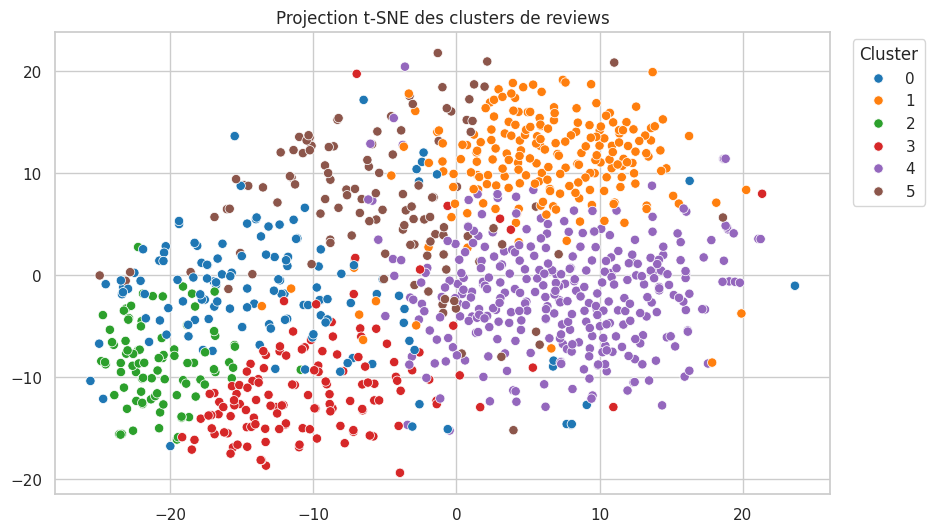

In [18]:
sample_size = min(1000, len(df_topic))
sample_idx = np.random.RandomState(42).choice(len(df_topic), size=sample_size, replace=False)

X_sample = X_emb[sample_idx]
labels_sample = df_topic.iloc[sample_idx]['cluster_kmeans'].to_numpy()

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_sample, palette='tab10', s=45)
plt.title('Projection t-SNE des clusters de reviews')
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()


The visualization shows that some clusters are well separated, while others partially overlap.

Certain groups form compact and distinct regions, which indicates strong semantic similarity within those clusters. However, overlaps between clusters suggest that some themes are close or not clearly distinguishable.

This confirms that clustering captures global structure, but does not always produce sharply separated groups.

## Final comparison

### Preparing topic summaries for an LLM

This step creates a structured summary for each cluster using keywords and representative examples.

In [19]:
def build_topic_summary_for_llm(topic_words_dict, df, topic_col, text_col, n_examples=3):
    summaries = []
    for topic_id, words in topic_words_dict.items():
        examples = df[df[topic_col] == topic_id][text_col].head(n_examples).tolist()
        summaries.append({
            'topic_id': topic_id,
            'top_words': words,
            'examples': examples
        })
    return summaries

kmeans_llm_input = build_topic_summary_for_llm(
    topic_words_dict=cluster_keywords,
    df=df_topic,
    topic_col='cluster_kmeans',
    text_col='avis_en_embeddings',
    n_examples=3
)


### Generating a naming prompt for one topic

You turn the cluster summary into a prompt that asks for a short label, a one-sentence explanation, and a coherence judgment. This is a neat bridge between unsupervised modeling and manual topic interpretation.

In [20]:
def make_llm_prompt(topic_info):
    prompt = f'''
You are analyzing customer review topics.

Topic ID: {topic_info['topic_id']}
Top words: {', '.join(topic_info['top_words'])}

Examples:
'''
    for i, ex in enumerate(topic_info['examples'], 1):
        prompt += f'\nExample {i}: {ex}\n'
    prompt += '''

Task:
1. Give a short topic label.
2. Explain the main theme in one sentence.
3. Say whether the topic seems coherent or mixed.
'''
    return prompt

print(make_llm_prompt(kmeans_llm_input[0]))



You are analyzing customer review topics.

Topic ID: 0
Top words: contract, hope, simple, direct, moment, car, easy, olivier, event, quick

Examples:

Example 1: very affordable price several options are available to us such as the box connected to the car the reassurance option and zero franchise which is quite pleasant

Example 2: new customer satisfied with the price and services I will not give more opinions because I am a new customer with you I hope everything goes well thank you

Example 3: the magnificent price I am interested I recommend it for everyone it is simpler and practical just the green sticker I did not receive for my first car


Task:
1. Give a short topic label.
2. Explain the main theme in one sentence.
3. Say whether the topic seems coherent or mixed.



The generated prompt combines keywords and representative examples to provide enough context for interpretation.

It guides the language model to produce a short label, a concise explanation, and a judgment on topic coherence.

This step transforms raw clustering outputs into structured, interpretable insights.

### Comparing the two topic-discovery approaches

This step compares LDA and embedding-based clustering using coherence and diversity scores.

In [21]:
results_topics = pd.DataFrame({
    'Method': ['LDA ', 'Embeddings + KMeans'],
    'Coherence': [lda_coherence, cluster_coherence],
    'Topic_Diversity': [lda_diversity, cluster_diversity]
})

results_topics


,Method,Coherence,Topic_Diversity
0,LDA,0.546743,0.960000
1,Embeddings + KMeans,0.554455,0.816667


Both approaches show strong performance, but with different strengths.

The embedding-based method achieves a slightly higher coherence score, indicating better semantic consistency within clusters. In contrast, LDA shows a higher topic diversity, suggesting a clearer separation between themes.

This highlights a trade-off between the two methods. Clustering captures semantic similarity more effectively, while LDA produces more distinct and interpretable topics.

Overall, LDA remains more structured for topic extraction, whereas embeddings provide a more flexible and semantically rich grouping of reviews.

### Visualizing the final topic-model comparison

This step visualizes coherence and diversity scores for both approaches.

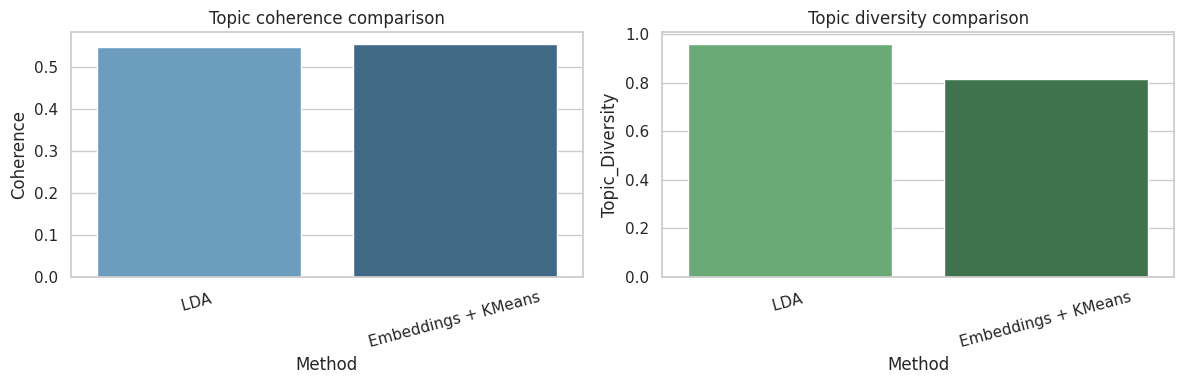

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=results_topics, x='Method', y='Coherence', ax=axes[0], palette='Blues_d')
axes[0].set_title('Topic coherence comparison')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=results_topics, x='Method', y='Topic_Diversity', ax=axes[1], palette='Greens_d')
axes[1].set_title('Topic diversity comparison')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


The visualization confirms the trade-off between the two methods.

Clustering achieves higher coherence, while LDA shows higher topic diversity. This reflects the difference between semantic grouping and clearer topic separation.

Overall, both approaches perform well, but serve slightly different objectives in topic discovery.

## Global conclusion

The preprocessing makes a real difference here: the notebook no longer relies only on raw high-frequency words, and both topic-discovery pipelines become more interpretable. For LDA, the coherence search points to **5 topics** as the best setting, with a coherence score of `0.547`. The topic diversity is also very strong (`0.96`), which means the model avoids repeating the same vocabulary too heavily across topics. That is a good sign for interpretability.

The embedding-based pipeline performs slightly better on coherence: **`Embeddings + KMeans`** reaches `0.555` coherence, compared with `0.547` for LDA. Its diversity is lower (`0.817` versus `0.96`), but still high enough to suggest that the clusters are not collapsing into the same keyword lists. Taken together, that means the embedding-plus-clustering approach produces the best balance in this notebook if your main criterion is semantic coherence, while LDA remains a very solid alternative if you value a bit more lexical separation between topics.

If you need to choose one final topic model from these results, the best option is **`Embeddings + KMeans`** because it delivers the highest coherence while keeping diversity at a good level. It looks like the strongest overall method in the current comparison. LDA is still valuable, though, especially if you want a more classical and often easier-to-explain topic model for presentation.


## Zero-shot review classification

The previous sections focused on **unsupervised theme discovery**. That is useful when you want latent themes to emerge from the corpus, but it does not fully solve the assignment requirement of **categorizing unlabeled reviews with predefined labels**.

The next section adds that missing piece. Instead of discovering topics first and naming them afterward, we now define a set of business-oriented categories in advance and ask a zero-shot model to assign the most plausible category to each review.

## Why zero-shot classification is different from topic modelling

Topic modelling and zero-shot classification answer two different questions.

Topic modelling asks: **"What themes seem to emerge naturally from the reviews?"**
Zero-shot classification asks: **"Given a fixed list of categories, which one best matches this review?"**

In [23]:
from transformers import pipeline

## Choosing the review text to classify

To stay consistent with the earlier embedding-based section, the zero-shot step uses the English review text stored in `avis_en_embeddings`. This keeps the language stable for the classifier and avoids mixing different preprocessing stages.

The idea is simple: every row is still unlabeled from the perspective of category assignment, but each row already contains review text that can be matched against a predefined list of candidate labels.

In [29]:
zero_shot_df = df_topic['clean_lda_text']

print(zero_shot_df.shape)
zero_shot_df.head()


(5989,)


,clean_lda_text
0,solutions listening speed attractive quality s...
1,generally problem internal impossible declare ...
2,affordable options available box connected car...
3,quick response cheapest market
4,disappointed mutual longer mutual search immed...


## Defining candidate review categories

Unlike topic modelling, zero-shot classification requires an explicit label space.

These labels are not the only possible choice. In practice, you can refine them depending on the report you want to write, but they already cover several common themes in insurance reviews: price, support quality, claims, digital experience, and contract administration.

In [30]:
candidate_labels = [
    'pricing and value',
    'customer service quality',
    'claims handling',
    'website or app usability',
    'contract management',
    'speed and responsiveness',
    'coverage and guarantees',
    'billing and payments',
    'general satisfaction'
]

candidate_labels

['pricing and value',
 'customer service quality',
 'claims handling',
 'website or app usability',
 'contract management',
 'speed and responsiveness',
 'coverage and guarantees',
 'billing and payments',
 'general satisfaction']

## Loading the zero-shot model

`facebook/bart-large-mnli` is one of the most common baseline models for zero-shot text classification. It was not trained specifically on your review labels, but it can still compare a review against candidate category descriptions and estimate which label is the best semantic match.

This is exactly why the method is attractive in a notebook like this one: you do not need a manually labeled training set before assigning categories.

In [31]:
zero_shot_classifier = pipeline(
    task='zero-shot-classification',
    model='facebook/bart-large-mnli'
)

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

## Assigning one main category to each unlabeled review

This first pass uses **single-label classification**. For each review, the model ranks all candidate categories and returns the best one with a confidence score.

The hypothesis template matters because it turns every label into a short natural-language statement. In other words, the model is not just matching words mechanically; it is comparing the review with hypotheses such as *"This customer review is mainly about pricing and value."*

In [34]:
zero_shot_df = df_topic[['clean_lda_text']].copy()

BATCH_SIZE = 16
hypothesis_template = 'This customer review is mainly about {}.'

texts = zero_shot_df['clean_lda_text'].tolist()
zero_shot_results = []

for start in range(0, len(texts), BATCH_SIZE):
    batch = texts[start:start + BATCH_SIZE]
    batch_results = zero_shot_classifier(
        batch,
        candidate_labels=candidate_labels,
        hypothesis_template=hypothesis_template,
        multi_label=False
    )

    if isinstance(batch_results, dict):
        batch_results = [batch_results]

    zero_shot_results.extend(batch_results)

zero_shot_df['predicted_label'] = [result['labels'][0] for result in zero_shot_results]
zero_shot_df['predicted_score'] = [float(result['scores'][0]) for result in zero_shot_results]
zero_shot_df['ranked_labels'] = [result['labels'] for result in zero_shot_results]
zero_shot_df['ranked_scores'] = [result['scores'] for result in zero_shot_results]

zero_shot_df[['clean_lda_text', 'predicted_label', 'predicted_score']].head(10)


,clean_lda_text,predicted_label,predicted_score
0,solutions listening speed attractive quality s...,speed and responsiveness,0.757097
1,generally problem internal impossible declare ...,customer service quality,0.262968
2,affordable options available box connected car...,pricing and value,0.346867
3,quick response cheapest market,speed and responsiveness,0.569270
4,disappointed mutual longer mutual search immed...,coverage and guarantees,0.448879
5,forced sale claiming events loved ones knowing...,claims handling,0.638102
6,hope,general satisfaction,0.262559
7,contacted sell puppy selling pretty details su...,claims handling,0.231846
8,join negative reviews regret having star reimb...,claims handling,0.312738
9,generali life assets poor payer ask advance ge...,pricing and value,0.151959


## Confidence-Based Validation for Zero-Shot Predictions
Zero-shot classification is useful for exploration, but low-confidence assignments should not be presented as strong evidence. We therefore inspect confidence scores explicitly and later isolate a higher-confidence subset.


## Understanding the category distribution

Once every review has a predicted category, you can inspect the global distribution. This is the point where the method becomes directly useful for reporting, because you no longer only have abstract topic IDs or clusters: you have interpretable category names assigned to real reviews.

In [35]:
zero_shot_counts = (
    zero_shot_df['predicted_label']
    .value_counts()
    .rename_axis('label')
    .reset_index(name='count')
)

zero_shot_counts

,label,count
0,speed and responsiveness,1876
1,coverage and guarantees,1154
2,claims handling,1102
3,pricing and value,480
4,customer service quality,368
5,general satisfaction,356
6,billing and payments,322
7,contract management,302
8,website or app usability,29


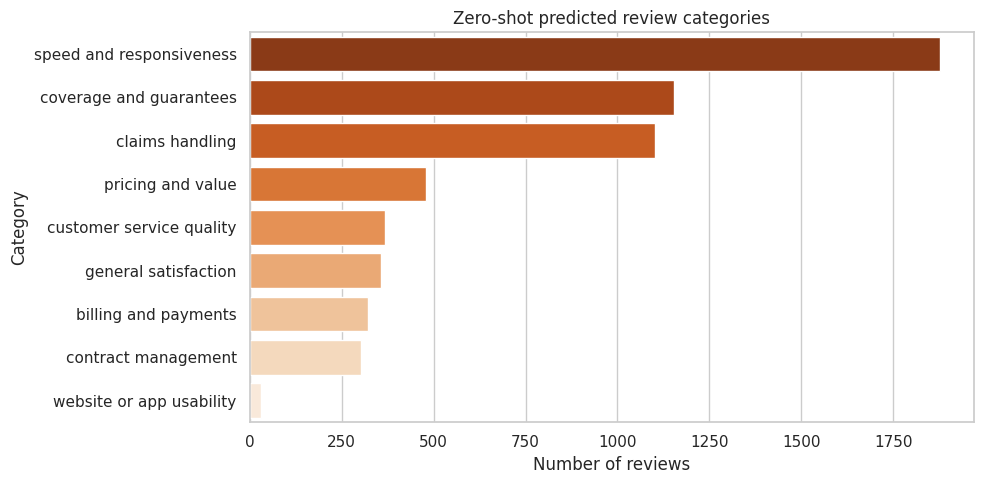

In [36]:
plt.figure(figsize=(10, 5))
sns.barplot(data=zero_shot_counts, x='count', y='label', palette='Oranges_r')
plt.title('Zero-shot predicted review categories')
plt.xlabel('Number of reviews')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

## Reading representative high-confidence examples

A zero-shot label is much easier to trust when you inspect confident examples manually. This qualitative step mirrors what you already did for LDA topics and KMeans clusters: the model output is more convincing when you connect it back to the original review text.

In [38]:
def show_zero_shot_examples(df, label_col, text_col, score_col, n_examples=3):
    for label in sorted(df[label_col].unique()):
        print('=' * 100)
        print(f'CATEGORY: {label}')
        subset = df[df[label_col] == label].sort_values(score_col, ascending=False).head(n_examples)
        for _, row in subset.iterrows():
            print(f'Score: {row[score_col]:.3f}')
            print(row[text_col])
            print()

show_zero_shot_examples(
    zero_shot_df,
    label_col='predicted_label',
    text_col='clean_lda_text',
    score_col='predicted_score',
    n_examples=3
)

CATEGORY: billing and payments
Score: 0.826
hello work march october received additional salary mutual shame work answer know waiting just waiting bills waiting hand deduct account mutual problems real shame mutual tomorrow going start procedures longer impossible cuddly

Score: 0.800
hello extremely disappointed member sick leave ago overall problem surprise payment march impossible payment impact situation longer able pay rent bills meals talking minimum subsistence level

Score: 0.685
conflict following burglary going half support intervention fend secure house miles away payment invoices validated expert icing cake increase premium date lousy conditions canceled

CATEGORY: claims handling
Score: 0.804
different agent poor management files response letters sent loss letters relocation death expert burglary expert yes car expert pre civil liability

Score: 0.738
mutual care reimbursed takes names just money expensive hard going complaint fed losers gets clogged does bother

Score: 0.

## Keeping a high-confidence labeled subset

Zero-shot predictions are useful, but not all of them are equally reliable. A simple confidence threshold lets you separate stronger assignments from more uncertain ones.

This is often a practical compromise in applied NLP work:

- keep all predictions for broad descriptive analysis;
- keep only high-confidence predictions for a cleaner labeled subset.

In [39]:
CONFIDENCE_THRESHOLD = 0.50

zero_shot_high_conf = zero_shot_df[zero_shot_df['predicted_score'] >= CONFIDENCE_THRESHOLD].copy()
print('High-confidence subset shape:', zero_shot_high_conf.shape)
zero_shot_high_conf[['clean_lda_text', 'predicted_label', 'predicted_score']].head(10)

High-confidence subset shape: (884, 5)


,clean_lda_text,predicted_label,predicted_score
0,solutions listening speed attractive quality s...,speed and responsiveness,0.757097
3,quick response cheapest market,speed and responsiveness,0.569270
5,forced sale claiming events loved ones knowing...,claims handling,0.638102
22,happy hoping follow received praise regarding ...,coverage and guarantees,0.790363
32,efficient quickly takes called happy say,speed and responsiveness,0.642412
36,simple quick information highly young people a...,speed and responsiveness,0.582787
38,rapid processing pleasure fast efficient inter...,speed and responsiveness,0.890820
39,live affordable interesting hoping necessary j...,speed and responsiveness,0.550232
46,responsiveness report moment olivier assurance...,coverage and guarantees,0.742101
51,flee quickly possible attractive increase subs...,speed and responsiveness,0.767139


## Optional multi-label classification

Some customer reviews mention several issues at once. A review may praise the advisor, complain about the website, and mention pricing in the same text. In those cases, a single-label decision can be too restrictive.

The cell below illustrates a **multi-label** variant, where the model scores every category independently. This is not required to satisfy the assignment, but it is a useful extension because real reviews are often mixed.

In [40]:
sample_multi = zero_shot_df['clean_lda_text'].head(5).tolist()
multi_label_results = zero_shot_classifier(
    sample_multi,
    candidate_labels=candidate_labels,
    hypothesis_template=hypothesis_template,
    multi_label=True
)

for text, result in zip(sample_multi, multi_label_results):
    print('-' * 100)
    print(text)
    display(pd.DataFrame({
        'label': result['labels'],
        'score': result['scores']
    }).head(5))

----------------------------------------------------------------------------------------------------
solutions listening speed attractive quality speed


,label,score
0,speed and responsiveness,0.979781
1,customer service quality,0.092958
2,general satisfaction,0.020188
3,pricing and value,0.017252
4,coverage and guarantees,0.015916


----------------------------------------------------------------------------------------------------
generally problem internal impossible declare attempts declaration competent pleasant interlocutor


,label,score
0,customer service quality,0.313004
1,speed and responsiveness,0.133524
2,claims handling,0.023122
3,general satisfaction,0.014319
4,contract management,0.010390


----------------------------------------------------------------------------------------------------
affordable options available box connected car reassurance option zero franchise quite pleasant


,label,score
0,pricing and value,0.892398
1,coverage and guarantees,0.816056
2,general satisfaction,0.766317
3,speed and responsiveness,0.132265
4,claims handling,0.048647


----------------------------------------------------------------------------------------------------
quick response cheapest market


,label,score
0,speed and responsiveness,0.985208
1,pricing and value,0.731061
2,customer service quality,0.341319
3,coverage and guarantees,0.255566
4,general satisfaction,0.226292


----------------------------------------------------------------------------------------------------
disappointed mutual longer mutual search immediate profit priority agency know try cheat useless contracts pay legal protection defended soon slightest disaster defend contrary automatically wrongs lower bonus high short goal pay possible unfortunately lot try pay little possible need


,label,score
0,coverage and guarantees,0.755218
1,contract management,0.530219
2,claims handling,0.351351
3,billing and payments,0.015259
4,speed and responsiveness,0.014079


## Final comparison: topic discovery versus category assignment

At this stage, the notebook contains two complementary families of methods.

The first family is **unsupervised**:

- improved LDA;
- Word2Vec document embeddings;
- KMeans clustering;
- keyword extraction and representative-example inspection.

The second family is **label-driven without supervised training data**:

- zero-shot classification with a predefined list of business categories.

This gives you a much stronger final story for the project. You can now say that the notebook does both of the following:

1. it explores the review corpus to discover latent themes;
2. it assigns explicit categories to unlabeled reviews using a zero-shot model.

That means the notebook is no longer limited to interpretive topic modelling alone. It now also addresses the assignment requirement of using a few-shot or zero-shot style categorization method for unlabeled reviews.